In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


print("=" * 60)
print("  SMART PRODUCT CATEGORY ASSISTANT – K-Means Clustering")
print("  NIM: 38250016")
print("=" * 60)

  SMART PRODUCT CATEGORY ASSISTANT – K-Means Clustering
  NIM: 38250016


In [2]:
DATASET_FILE = "Online Sales Data.csv"

if os.path.exists(DATASET_FILE):
    df_raw = pd.read_csv(DATASET_FILE)
    print(f"\n[1] DATASET BERHASIL DIMUAT: '{DATASET_FILE}'")
else:
    raise FileNotFoundError(f"File '{DATASET_FILE}' tidak ditemukan! Pastikan Anda sudah mengupload file ke panel Files di kiri Colab.")

print(f"    Total data yang dimuat: {len(df_raw)} baris")


[1] DATASET BERHASIL DIMUAT: 'Online Sales Data.csv'
    Total data yang dimuat: 300 baris


In [3]:
print("\n[2] PREPROCESSING & SCALING")
FEATURES = ["Units Sold", "Unit Price"]
df = df_raw.dropna(subset=FEATURES).copy()
X = df[FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("    Statistik Deskriptif Fitur Utama (Skala Asli):")
display(X.describe().round(2))  # Menggunakan display agar tabel di Colab terlihat lebih rapi


[2] PREPROCESSING & SCALING
    Statistik Deskriptif Fitur Utama (Skala Asli):


,Units Sold,Unit Price
count,300.00,300.00
mean,149.37,323.82
std,134.34,346.72
min,5.00,7.39
25%,52.75,65.78
50%,99.00,209.34
75%,195.25,439.10
max,569.00,1491.96



[3] EVALUASI PENENTUAN CLUSTER OPTIMAL


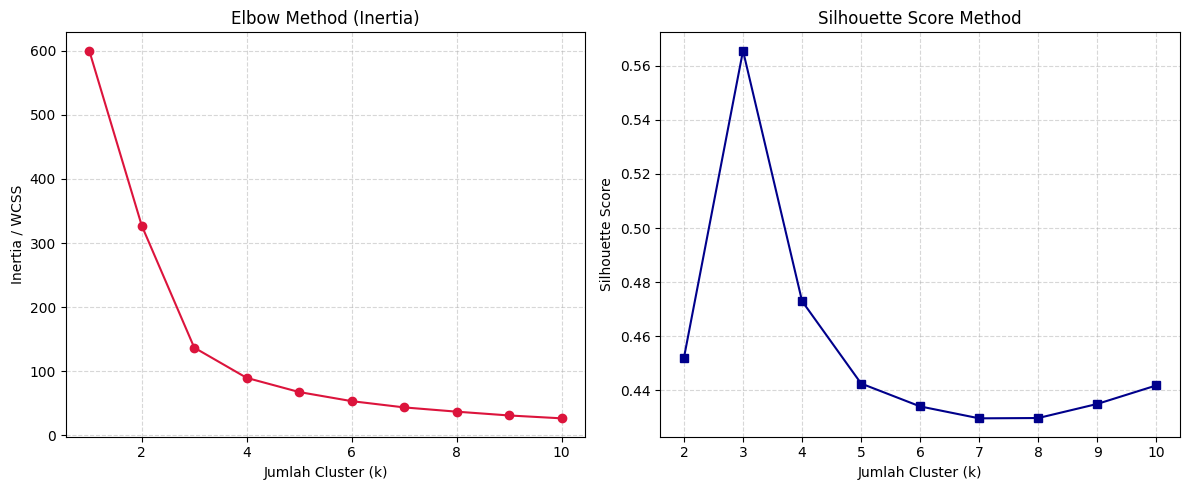

In [4]:
print("\n[3] EVALUASI PENENTUAN CLUSTER OPTIMAL")
inertias = []
sil_scores = []
k_values = range(2, 11)

# Hitung WCSS untuk K=1 khusus untuk grafik Elbow
kmeans_k1 = KMeans(n_clusters=1, init='k-means++', random_state=42, n_init=10).fit(X_scaled)
inertias.append(kmeans_k1.inertia_)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plotting Evaluasi K (Elbow vs Silhouette) secara interaktif
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(range(1, 11), inertias, marker="o", color="crimson")
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("Jumlah Cluster (k)")
ax[0].set_ylabel("Inertia / WCSS")
ax[0].grid(True, ls='--', alpha=0.5)

ax[1].plot(k_values, sil_scores, marker="s", color="darkblue")
ax[1].set_title("Silhouette Score Method")
ax[1].set_xlabel("Jumlah Cluster (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show() # Grafik otomatis digambar di bawah sel Colab ini

In [5]:
print("\n[4] TRAINING MODEL K-MEANS")
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

print(f"    Model K-Means konvergen pada iterasi ke-{kmeans.n_iter_}")
print(f"    Final Inertia (WCSS): {kmeans.inertia_:.4f}")
print(f"    Final Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")


[4] TRAINING MODEL K-MEANS
    Model K-Means konvergen pada iterasi ke-5
    Final Inertia (WCSS): 136.8328
    Final Silhouette Score: 0.5656


In [6]:
print("\n[5] PROFILING CLUSTER (RATA-RATA NILAI ASLI)")
profil = df.groupby('Cluster')[FEATURES].mean()
profil['Total Revenue'] = df.groupby('Cluster')['Total Revenue'].mean()
display(profil.round(2))

# Pemetaan Label Berdasarkan Karakteristik Cluster
cluster_mapping = {}
for cid in profil.index:
    price = profil.loc[cid, 'Unit Price']
    units = profil.loc[cid, 'Units Sold']

    if price > profil['Unit Price'].median() and units < profil['Units Sold'].median():
        cluster_mapping[cid] = "💎 PREMIUM STARS"
    elif units > profil['Units Sold'].median():
        cluster_mapping[cid] = "🔥 VOLUME DRIVERS"
    else:
        cluster_mapping[cid] = "🛒 STANDARD ITEMS"

print("\n    Interpretasi Hasil Segmentasi:")
for cid, label in cluster_mapping.items():
    print(f"    Cluster {cid} -> {label}")


[5] PROFILING CLUSTER (RATA-RATA NILAI ASLI)


,Units Sold,Unit Price,Total Revenue
Cluster,,,
0,93.73,255.37,20749.83
1,371.24,88.37,30436.65
2,49.86,1108.29,55336.43



    Interpretasi Hasil Segmentasi:
    Cluster 0 -> 🛒 STANDARD ITEMS
    Cluster 1 -> 🔥 VOLUME DRIVERS
    Cluster 2 -> 💎 PREMIUM STARS



[6] VISUALISASI HASIL CLUSTERING


C:\Users\KJL\AppData\Local\Temp\ipykernel_7900\680501064.py:20: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KJL\AppData\Local\Temp\ipykernel_7900\680501064.py:20: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KJL\AppData\Local\Temp\ipykernel_7900\680501064.py:20: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\KJL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KJL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KJL\AppData\Local\Programs\Python\Python312\Lib\site-packages\

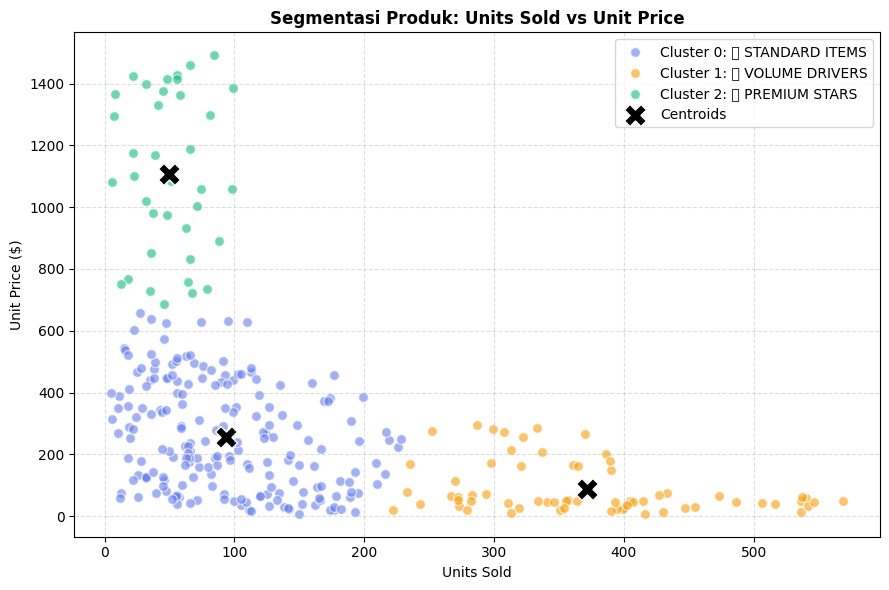

In [7]:
print("\n[6] VISUALISASI HASIL CLUSTERING")
centroids_scaled = kmeans.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids_scaled)

palette = {0: '#667eea', 1: '#f59e0b', 2: '#10b981'}

plt.figure(figsize=(9, 6))

for cid in sorted(df['Cluster'].unique()):
    m = df['Cluster'] == cid
    plt.scatter(df.loc[m, 'Units Sold'], df.loc[m, 'Unit Price'],
                c=palette[cid], label=f"Cluster {cid}: {cluster_mapping[cid]}", alpha=0.6, edgecolors='white', s=50)

plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1], c='black', marker='X', s=250, label='Centroids', edgecolors='white')
plt.title('Segmentasi Produk: Units Sold vs Unit Price', fontweight='bold', fontsize=12)
plt.xlabel('Units Sold')
plt.ylabel('Unit Price ($)')
plt.legend()
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show() # Grafik sebaran cluster otomatis digambar di bawah sel ini

In [9]:
print("\n[7] MENYIMPAN MODEL & DATA")
os.makedirs('models', exist_ok=True) # Create the directory if it doesn't exist
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
df.to_csv("models/dataset_clustered.csv", index=False)
print("    Semua file sukses disimpan di folder 'models/'")
print("    Anda bisa mendownload file .pkl dari folder 'models' di panel kiri untuk dipakai di Streamlit lokal.")


[7] MENYIMPAN MODEL & DATA
    Semua file sukses disimpan di folder 'models/'
    Anda bisa mendownload file .pkl dari folder 'models' di panel kiri untuk dipakai di Streamlit lokal.


In [10]:
print("\n[8] CONTOH PREDIKSI PRODUK BARU")
test_samples = [
    {"name": "Luxury Smart Watch",    "units": 12,  "price": 899.99},
    {"name": "Basic Phone Case",      "units": 350, "price": 9.99},
    {"name": "Standard Headphones",   "units": 55,  "price": 79.99},
]

for s in test_samples:
    X_new = np.array([[s["units"], s["price"]]])
    X_new_scaled = scaler.transform(X_new)
    pred_cid = int(kmeans.predict(X_new_scaled)[0])
    print(f"    {s['name']:<25} -> Masuk Cluster {pred_cid} ({cluster_mapping[pred_cid]})")

print("\n" + "=" * 60)
print("    PROSES SELESAI – Seluruh sel berhasil dieksekusi dengan visualisasi!")
print("=" * 60)


[8] CONTOH PREDIKSI PRODUK BARU
    Luxury Smart Watch        -> Masuk Cluster 2 (💎 PREMIUM STARS)
    Basic Phone Case          -> Masuk Cluster 1 (🔥 VOLUME DRIVERS)
    Standard Headphones       -> Masuk Cluster 0 (🛒 STANDARD ITEMS)

    PROSES SELESAI – Seluruh sel berhasil dieksekusi dengan visualisasi!


c:\Users\KJL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\KJL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\KJL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
